In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Perceptron import Perceptron
from AdalineGD import AdalineGD

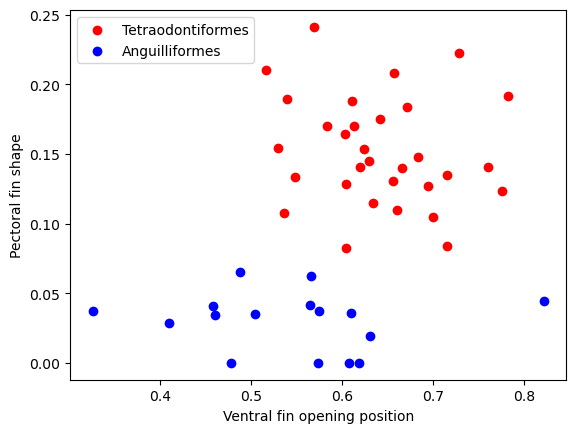

In [2]:
fish3 = pd.read_csv("fish3.csv")
order = np.array(fish3['Order'])
order1 = np.where(order == "Tetraodontiformes")
order2 = np.where(order == "Anguilliformes")
x1 = np.array(fish3["VEp"])
x2 = np.array(fish3["PFs"])

# display dataset
plt.scatter(x1[order1], x2[order1], color='red', label="Tetraodontiformes")
plt.scatter(x1[order2], x2[order2], color='blue', label="Anguilliformes")
plt.xlabel("Ventral fin opening position")
plt.ylabel("Pectoral fin shape")
plt.legend()
plt.show()

# format data for training
idcs = np.concatenate((order1, order2), 1)[0]
np.random.shuffle(idcs)
X = np.stack((x1[idcs], x2[idcs])).transpose()
y = np.where(order[idcs] == "Tetraodontiformes", 0.0, 1.0)

I am comparing robustness to random seed in Perceptron and Adaline models by looking at training errors over a range of 50 random seeds. For each random seed, the models are trained with a learning rate of 0.1 and for 30 iterations.

In [3]:
# train Perceptron and AdalineGD models over range of n random seeds
num_seeds = 50
lr = 0.1
n = 30
perceptrons = []
adas = []

for rs in range(num_seeds):
    perceptron = Perceptron(n_iter=n, eta=lr, random_state=rs)
    perceptron.fit(X, y)
    perceptrons.append(perceptron.errors_)
    ada_gd = AdalineGD(n_iter=n, eta=lr, random_state=rs)
    ada_gd.fit(X, y)
    adas.append(ada_gd.losses_)

perceptrons = np.array(perceptrons)
adas = np.array(adas)

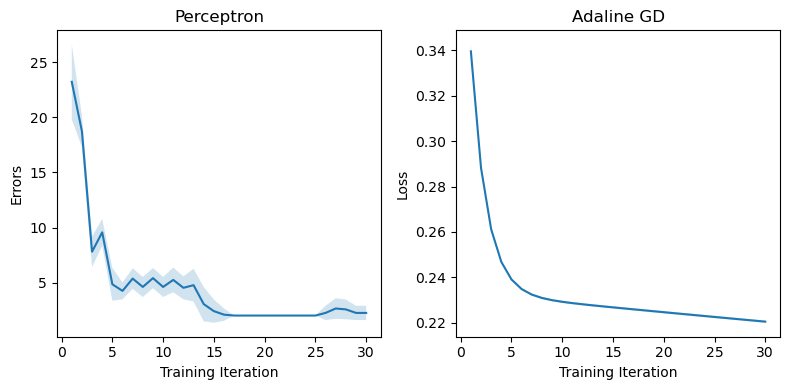

In [4]:
# display results
pmean = np.mean(perceptrons, axis=0)
pstd = np.std(perceptrons, axis=0)
amean = np.mean(adas, axis=0)
astd = np.std(adas, axis=0)

fig, axs = plt.subplots(1,2, figsize=(8,4))
axs[0].plot(range(1,n+1), pmean)
axs[0].fill_between(range(1,n+1), pmean-pstd, pmean+pstd, alpha=0.2)
axs[0].set_xlabel("Training Iteration")
axs[0].set_ylabel("Errors")
axs[0].set_title("Perceptron")

axs[1].plot(range(1,n+1), amean)
axs[1].fill_between(range(1,n+1), amean-astd, amean+astd, alpha=0.2)
axs[1].set_xlabel("Training Iteration")
axs[1].set_ylabel("Loss")
axs[1].set_title("Adaline GD")

plt.tight_layout()

The figure shows mean (line) and standard deviation (shaded) of y-axis value at each training iteration. The mean/std are between the 50 trials with different random seeds. While different y-axis metrics means it isn't a direct comparison between Perceptron and Adaline models, it's clear that the adaline model is more consistent across seeds.